# Chapter 71 — Modeling Real Phenomena

> **Prerequisites:** ch070 (Function Families), ch017 (Mathematical Modeling)
>
> **You will learn:**
> - Apply the modeling cycle: observe → hypothesize → fit → validate
> - Choose an appropriate function family for a real dataset
> - Understand the difference between interpolation and extrapolation
> - Recognize when a model is wrong
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

**Mathematical modeling** is the process of representing a real-world phenomenon with a mathematical function.

The modeling cycle:
1. **Observe**: collect data or describe the phenomenon qualitatively
2. **Hypothesize**: propose a function family (linear? exponential? logistic?)
3. **Fit**: find parameter values that minimize error on observed data
4. **Validate**: test on held-out data; check assumptions
5. **Refine or reject**: revise hypothesis if validation fails

**Interpolation vs extrapolation:**
- Interpolation: predicting within the range of observed data — generally reliable
- Extrapolation: predicting beyond the data range — dangerous; model structure must be trusted

**When a model is wrong:**
- Residuals show systematic patterns (not random) → wrong function family
- Model fits training data but fails on new data → overfitting
- Model misses obvious features → underfitting or wrong family

*(Recall ch017: mathematical models are simplifications. All models are wrong; some are useful.)*

---

## 2. Intuition & Mental Models

**Physical analogy:** A weather forecast is a model. The model's function family (atmospheric equations) encodes physical laws. Parameter fitting uses observed pressure, temperature, humidity. Validation happens the next day. If the forecast is systematically wrong in a direction, the model structure needs revision.

**Computational analogy:** Machine learning is automated modeling. The algorithm searches over a hypothesis class (function family) and finds parameters that minimize error. The same cycle applies: train, validate, revise architecture.

---

## 3. Visualization

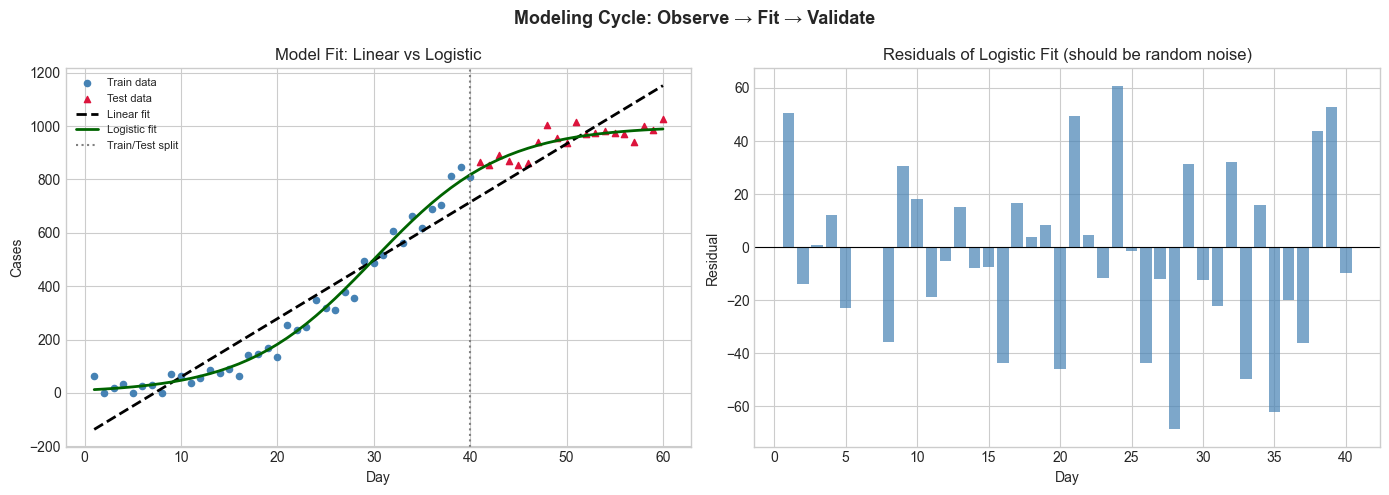

Linear model test RMSE: 87.4
Logistic model test RMSE: 30.7


In [1]:
# --- Visualization: The full modeling cycle on real-shaped data ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(7)

# Generate data from a logistic process (unknown to the modeler)
t = np.arange(1, 61)
K, r, t0 = 1000, 0.15, 30
true_y = K / (1 + np.exp(-r * (t - t0)))
observed = true_y + np.random.normal(0, 30, len(t))
observed = np.maximum(0, observed)

# Modeler's hypothesis 1: linear
t_train, t_test = t[:40], t[40:]
y_train, y_test = observed[:40], observed[40:]

# Fit linear model to training data
A = np.column_stack([t_train, np.ones(len(t_train))])
m_lin, b_lin = np.linalg.lstsq(A, y_train, rcond=None)[0]
y_pred_lin = m_lin * t + b_lin

# Fit logistic by simple grid search (preview of ch072)
best_err, best_params = np.inf, None
for K_try in [800, 1000, 1200]:
    for r_try in [0.1, 0.15, 0.2]:
        for t0_try in [25, 30, 35]:
            y_hat = K_try / (1 + np.exp(-r_try * (t_train - t0_try)))
            err = np.mean((y_hat - y_train)**2)
            if err < best_err:
                best_err, best_params = err, (K_try, r_try, t0_try)

Kb, rb, t0b = best_params
y_pred_log = Kb / (1 + np.exp(-rb * (t - t0b)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(t_train, y_train, color='steelblue', s=20, label='Train data')
ax.scatter(t_test, y_test, color='crimson', s=20, label='Test data', marker='^')
ax.plot(t, y_pred_lin, 'k--', linewidth=2, label=f'Linear fit')
ax.plot(t, y_pred_log, color='darkgreen', linewidth=2, label=f'Logistic fit')
ax.axvline(40, color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('Model Fit: Linear vs Logistic'); ax.set_xlabel('Day'); ax.set_ylabel('Cases')
ax.legend(fontsize=8)

# Residuals for logistic model
residuals = y_train - Kb/(1+np.exp(-rb*(t_train - t0b)))
axes[1].bar(t_train, residuals, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Residuals of Logistic Fit (should be random noise)')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Residual')

plt.suptitle('Modeling Cycle: Observe → Fit → Validate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

lin_test_err = np.sqrt(np.mean((y_pred_lin[40:] - y_test)**2))
log_test_err = np.sqrt(np.mean((y_pred_log[40:] - y_test)**2))
print(f"Linear model test RMSE: {lin_test_err:.1f}")
print(f"Logistic model test RMSE: {log_test_err:.1f}")

---

## 5. Python Implementation

In [2]:
# --- Implementation: Modeling pipeline ---
import numpy as np

class SimpleFitter:
    """Fit and evaluate a parameterized model using grid search."""
    
    def __init__(self, model_fn, param_grid):
        self.model_fn = model_fn
        self.param_grid = param_grid
        self.best_params = None
        self.best_mse = np.inf
    
    def fit(self, x, y):
        """Grid search over param_grid to minimize MSE."""
        import itertools
        keys = list(self.param_grid.keys())
        values = [self.param_grid[k] for k in keys]
        for combo in itertools.product(*values):
            params = dict(zip(keys, combo))
            try:
                y_hat = self.model_fn(x, **params)
                mse = np.mean((y - y_hat)**2)
                if mse < self.best_mse:
                    self.best_mse, self.best_params = mse, params
            except (ValueError, RuntimeWarning, FloatingPointError):
                continue
        return self
    
    def predict(self, x):
        return self.model_fn(x, **self.best_params)
    
    def score(self, x, y):
        y_hat = self.predict(x)
        ss_res = np.sum((y - y_hat)**2)
        ss_tot = np.sum((y - y.mean())**2)
        return 1 - ss_res / ss_tot  # R²

# Use on growth data
np.random.seed(0)
t = np.linspace(1, 50, 50)
y_true = 500 / (1 + np.exp(-0.2*(t - 25)))
y_obs = y_true + np.random.normal(0, 15, 50)

fitter = SimpleFitter(
    model_fn=lambda t, K, r, t0: K / (1 + np.exp(-r*(t - t0))),
    param_grid={'K': [400, 500, 600], 'r': [0.15, 0.2, 0.25], 't0': [20, 25, 30]}
)
fitter.fit(t, y_obs)
print("Best params:", fitter.best_params)
print("R² score:", fitter.score(t, y_obs).round(4))

Best params: {'K': 500, 'r': 0.2, 't0': 25}
R² score: 0.9919


---

## 6. Experiments

**Experiment 1:** Use the `SimpleFitter` on linear data with a logistic model. What happens? The logistic will try to fit a plateau where there is none — high residuals at the extremes.

**Experiment 2:** Vary the noise level (σ) from 5 to 100 and observe how the best fit degrades. At what noise level does model selection become unreliable?

---

## 7. Exercises

**Easy 1.** A population grows from 100 to 800 over 20 years. Which function family is most appropriate: linear, exponential, or logistic? Justify with one qualitative reason.

**Easy 2.** If residuals in a model show a clear wave pattern, what does this suggest about the model's function family?

**Medium 1.** Implement a train-test split evaluator: given data, a model fn, and a split ratio, fit on train and compute RMSE on test. Apply to at least two model families on the same dataset.

**Medium 2.** Generate data from y = 3x² + noise. Fit linear, quadratic, and cubic models. Which has lowest training error? Which has lowest test error?

**Hard.** Implement AIC (Akaike Information Criterion) model comparison: AIC = 2k - 2·log(L), where k is the number of parameters and L is the likelihood (assume Gaussian errors). Compare linear, quadratic, and cubic fits using AIC.

---

## 9. Chapter Summary & Connections

- Modeling cycle: observe → hypothesize family → fit → validate → refine
- Interpolation is reliable; extrapolation requires trust in the model structure
- Residuals should look like random noise — any pattern indicates model misspecification
- RMSE, R², AIC are quantitative tools for comparing models

**Forward connections:**
- ch072 (Fitting Simple Models) formalizes the parameter search
- ch073 (Error and Residuals) analyzes what residual patterns tell us
- ch287 (Model Evaluation) covers the full validation toolkit